In [131]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state
from metastable.jacobian_eigenvectors import calculate_jacobian_eigenvectors


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/00-attempt/map.npz")
epsilon_idx = 350
kappa_idx = 200

# epsilon_idx = 470
# kappa_idx = 299

# epsilon_idx = 457
# kappa_idx = 290

params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 2]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)

(601,)
(401,)
epsilon=17.5 delta=7.8 chi=-0.1 kappa=2.5
[-8.09057232  6.91452471] [-1.77742351  4.66097573]


In [132]:
eigenvalues, eigenvectors = calculate_jacobian_eigenvectors(keldysh_focus_point, params)

In [133]:
np.round(eigenvalues, 4)

array([-2.5+5.1638j, -2.5-5.1638j,  2.5+5.1638j,  2.5-5.1638j])

In [134]:
eigenvalues

array([-2.5+5.16383046j, -2.5-5.16383046j,  2.5+5.16383046j,
        2.5-5.16383046j])

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.74e-02       2.37e-08         10001            0       
Solved in 1 iterations, number of nodes 10001. 
Maximum relative residual: 1.74e-02 
Maximum boundary residual: 2.37e-08


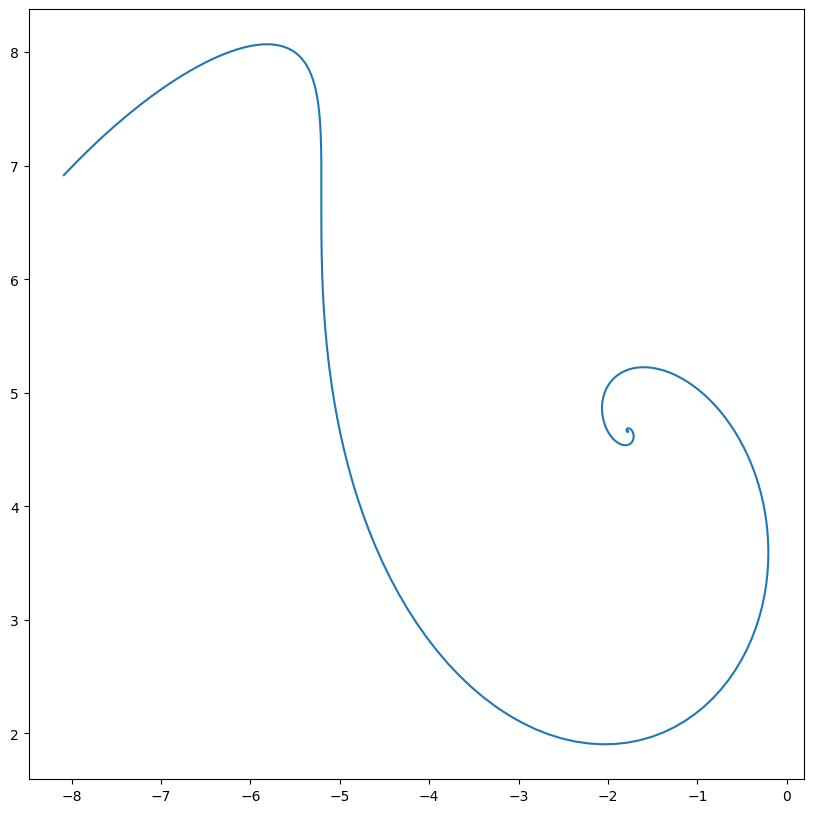

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  8.000e-04 ...  7.999e+00  8.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7f4f3b21c450>
             p: None
             y: [[-1.777e+00 -1.777e+00 ... -8.087e+00 -8.087e+00]
                 [ 4.661e+00  4.661e+00 ...  6.917e+00  6.917e+00]
                 [ 1.242e-04  1.238e-04 ... -1.874e-03 -1.871e-03]
                 [-1.092e-04 -1.099e-04 ...  4.944e-04  4.936e-04]]
            yp: [[-2.694e-04 -2.742e-04 ... -6.427e-03 -6.417e-03]
                 [-9.325e-04 -9.323e-04 ... -5.369e-03 -5.361e-03]
                 [-4.736e-04 -4.787e-04 ...  3.623e-03  3.617e-03]
                 [-9.076e-04 -9.084e-04 ... -9.607e-04 -9.593e-04]]
 rms_residuals: [ 1.813e-09  2.070e-09 ...  1.794e-08  1.854e-08]
         niter: 1


In [135]:
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def boundary_condition_func(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, boundary_condition_func, t_guess, y_guess, tol=1e-1, max_nodes=1000000, verbose=2
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(10, 10))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

print(res)

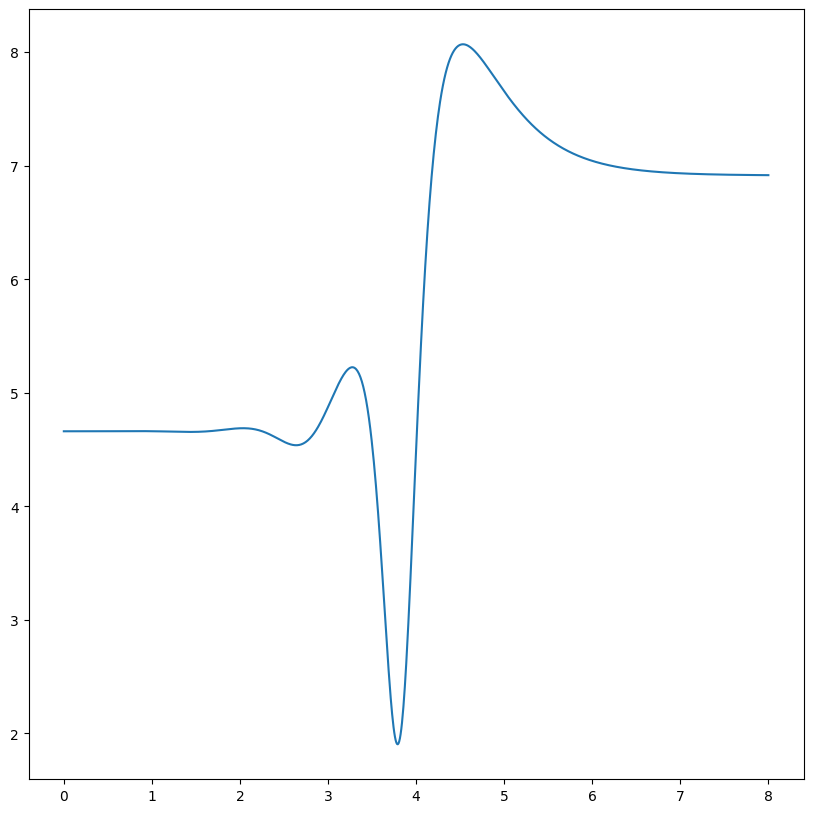

In [136]:
fig, axes = plt.subplots(1,1,figsize=(10, 10))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(t_plot,y1_plot)
plt.show()